In [1]:
import os
from pathlib import Path
os.chdir(Path("C:/Users/apaks/projects/blog-writing-agent"))

In [2]:
from pydantic import BaseModel, Field
from typing import TypedDict, List, Annotated, Literal
import operator
from dotenv import load_dotenv
import re

from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage, SystemMessage
from langgraph.types import Send
from langgraph.graph import StateGraph, START, END

from src.blog_writing_agent.utils import load_prompt

In [3]:
load_dotenv()

True

In [4]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ..., 
        description="One sentence describing what the reader should be able to do/understand after this section."
    )

    bullets: List[str] = Field(
        ...,
        min_length = 3,
        max_length = 5,
        description = "3-5 concrete, non-overlapping points to be covered in this section"
    )

    target_words: int = Field(
        ...,
        description= "Target word count for this section (120-450)"
    )

    section_type: Literal['intro', "core", "examples", "checklist", "common_mistakes", "conclusion"] = Field(
        ...,
        description = "Use 'common_mistakes' exactly once in the plan."
    )

    brief: str = Field(..., description = "What it covers..")

class Plan(BaseModel):
    blog_title: str
    audience: str = Field(..., description= "Who this blog is for.")
    tone: str = Field(..., description = "Writing tone(eg., practical, crisp).")
    tasks: List[Task]

In [5]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]            #results from workers get concatenated
    final: str

In [6]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

In [7]:
def orchestrator(state: State):
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(content= load_prompt("orchestrator_prompt")),
            HumanMessage(content= f'Topic: {state['topic']}')
        ]
    )

    return {"plan": plan}

In [8]:
# fanout - this is required so that the output from orchestrator (plan) is sent to multiple worker to perform task parallely 
def fanout(state: State):
    
    return [Send(
        "worker",
        {
            "task": task,
            "topic": state['topic'],
            "plan": state['plan']
        } 
    )for task in state['plan'].tasks]

In [9]:
def worker(payload:dict) -> dict:

    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md = llm.invoke(
        [
            SystemMessage(content = load_prompt("worker_system_prompt")),
            HumanMessage(content = (
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section Type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets: {bullets_text}"               
                )
            )
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [10]:
def reducer(state: State):
    """concatenates all the title and all the sections"""
    title = state["plan"].blog_title
    body = "\n\n".join(state['sections']).strip()

    final_md = f"# {title}\n\n{body}\n"

    # save the file 
    output_dir = Path("final_blogs")
    output_dir.mkdir(parents=True, exist_ok=True)
    title = re.sub(r'[<>:"/\\|?*]', "", title)
    file_name = title.lower().replace(" ", "_") + ".md"
    output_path = output_dir / file_name
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


Build the graph

In [11]:
graph = StateGraph(State)

graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)

graph.add_edge(START, "orchestrator")
graph.add_conditional_edges("orchestrator", fanout, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)

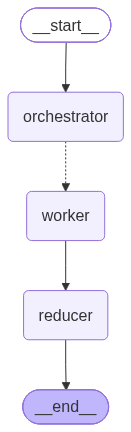

In [12]:
app = graph.compile()
app

In [13]:
out = app.invoke({"topic": "Self attention"})

In [14]:
out['final']

'# Mastering Self-Attention: From Fundamentals to Practical Implementation\n\n## Introduction to Self-Attention and Its Importance\n\nSelf-attention is a mechanism that allows a model to relate different positions within a single input sequence to compute a representation of that sequence. Unlike traditional attention, which typically involves two distinct sequences—such as a query and a context (e.g., encoder-decoder attention in machine translation)—self-attention operates on one sequence alone. Each element in the sequence attends to all other elements, enabling the model to weigh their importance dynamically.\n\nSelf-attention has become foundational in modern deep learning architectures, notably the Transformer model. It has revolutionized performance in natural language processing (NLP) tasks such as machine translation, text summarization, and language modeling. Beyond NLP, self-attention extends to computer vision through Vision Transformers (ViT), where pixels or patches atten